In [1]:
import astropy.coordinates as coord
import astropy.units as u
import numpy as np
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic

import numpy as np
import matplotlib.pyplot as plt 

sim_data_carthesian: [[-4.4139624e+00 -6.6968746e+00  5.9942584e+00 -1.4980000e+02
   2.9982208e+02 -2.7242739e+01]
 [ 5.7467687e-01 -2.4242349e+00  3.2582760e-01 -6.4715826e+02
  -1.3444030e+03  1.0411720e+03]
 [-9.6119976e-01  1.3850372e+00 -3.5226822e-01  7.5218286e+02
   1.2779473e+03 -1.2091208e+03]
 ...
 [-3.1430173e+00 -7.7249012e+00  5.7997952e+00 -2.4358350e+02
   1.3578430e+02  1.1713970e+02]
 [-3.5924706e+00 -7.2238464e+00  5.9303555e+00 -1.7765070e+02
   2.8756210e+02 -2.3994284e+01]
 [-7.6208353e-01 -6.4439139e+00  3.5658939e+00 -4.3854904e+02
  -6.6884241e+02  6.5668274e+02]]
sim_data_projected: [[ 189.34057633  -24.72328495    9.70977243   -2.4438106     1.25284414
  -121.07583072]
 [ 253.42477456  -40.51892012    9.03336493  -44.01209901  -15.65385684
  -173.86014993]
 [ 275.03455869  -20.79061386    7.30302585   41.64123494    6.3890764
   982.83420223]
 ...
 [ 192.6566181   -30.63008504   10.85637541   -5.34230063    2.28768557
    18.72490009]
 [ 191.99452707  -28.06

Text(0, 0.5, 'y [kpc]')

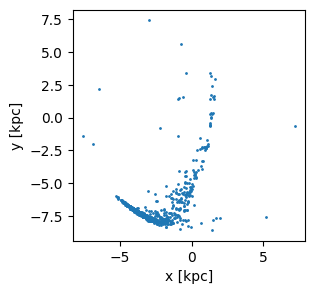

In [15]:
# i = 3
i = 9
data = np.load(f'../project_stream/data/streams/data/simulation_{i}.npz')
sim_data = data['sim_data_carthesian']

for k in data.keys():
    print(f"{k}: {data[k]}")

fig = plt.figure(figsize=(3, 3))
plt.scatter(sim_data[:, 0], sim_data[:, 1], s=1)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')


j = 2 is NGC3201 !


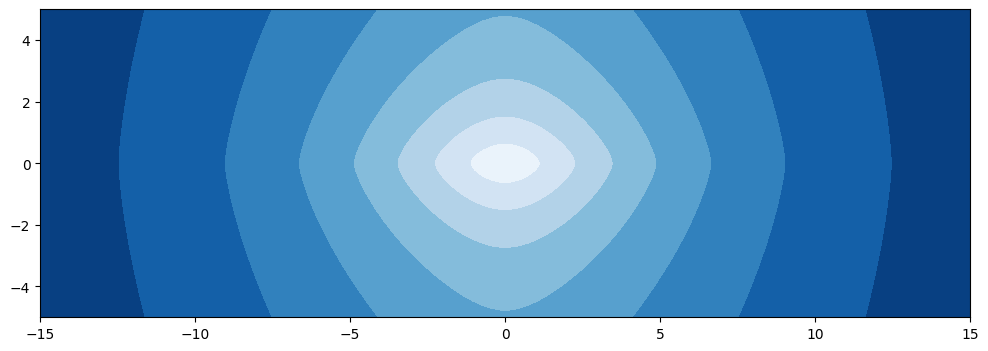

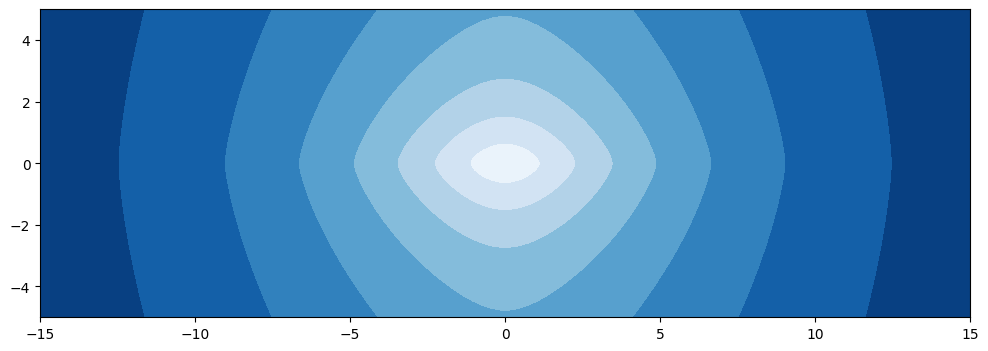

In [27]:
print('j =',data['j'][0], 'is NGC3201 !')

pot = gp.CCompositePotential()

pot['halo'] = gp.NFWPotential(m     = data['m_Triaxial_halo'][0],
                              r_s   = data['r_Triaxial_halo'][0],
                              a     = 1,
                              b     = data['q1_Triaxial_halo'][0],
                            #   c     = data['q2_Triaxial_halo'][0],
                             c = 5,
                              units =galactic)

pot['thin_disk'] = gp.MN3ExponentialDiskPotential(m = 4 * np.pi * data['rho_thin_disk'][0]*data['hr_thin_disk'][0]**2 * data['hz_thin_disk'][0],
                                                h_R=data['hr_thin_disk'][0],
                                                h_z=data['hz_thin_disk'][0],
                                                units=galactic,
                                                positive_density=True)
pot['thick_disk'] = gp.MN3ExponentialDiskPotential(m = 4 * np.pi * data['rho_thick_disk'][0] *data['hr_thick_disk'][0]**2 * data['hz_thick_disk'][0],
                                                 h_R=data['hr_thick_disk'][0],
                                                 h_z=data['hz_thick_disk'][0],
                                                 units=galactic,
                                                 positive_density=True)
pot['bulge'] = gp.PowerLawCutoffPotential(m=data['m_bulge'][0],
                                          r_c=data['r_bulge'][0],
                                          alpha=data['alpha_bulge'][0],
                                          units=galactic)

w0 = coord.Galactocentric(x=data['x'][0]*u.kpc, y=data['y'][0]*u.kpc, z=data['z'][0]*u.kpc,
                          v_x=data['vx'][0]*u.km/u.s, v_y=data['vy'][0]*u.km/u.s, v_z=data['vz'][0]*u.km/u.s)
w0 = gd.PhaseSpacePosition(w0)

prog_mass = data['m_progenitor'][0] * u.Msun
b_prog = data['a_progenitor'][0] * u.pc
NGC3201_pot = gp.PlummerPotential(m=prog_mass, b=b_prog, units=galactic)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
x = np.linspace(-15, 15, 100)
z = np.linspace(-5, 5, 100)
pot.plot_contours(grid=(x, 1.0, z), ax=ax)

In [31]:
from gala.dynamics import mockstream as ms
df = gd.ChenStreamDF()

gen_NGC3201 = ms.MockStreamGenerator(df, pot,
                                  progenitor_potential=NGC3201_pot)
NGC3201_stream, _ = gen_NGC3201.run(w0, prog_mass,
                                    dt=-1.5*u.Myr, n_steps=500, )

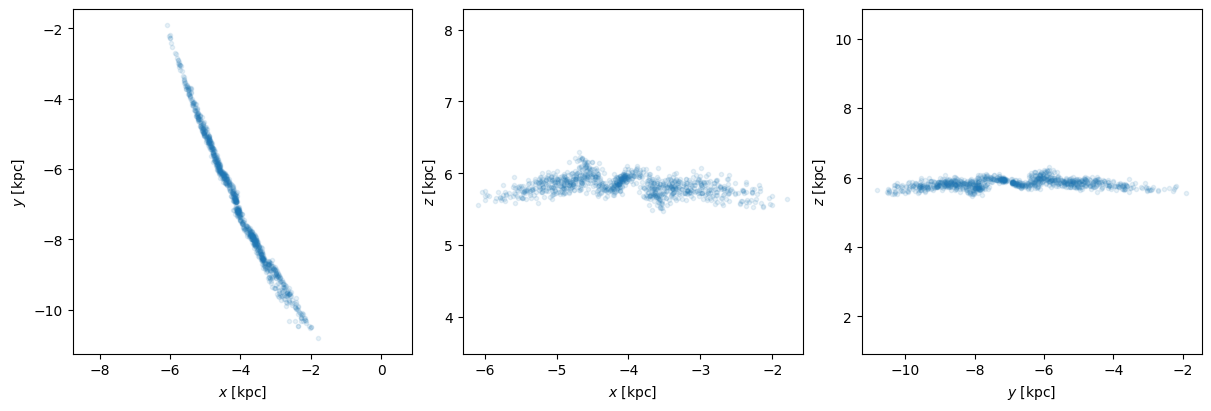

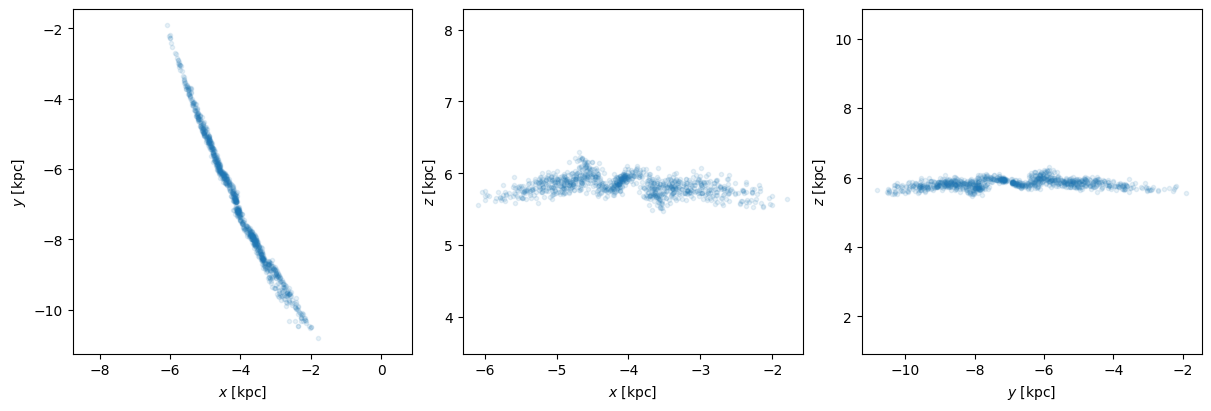

In [32]:
NGC3201_stream.plot(alpha=0.1)


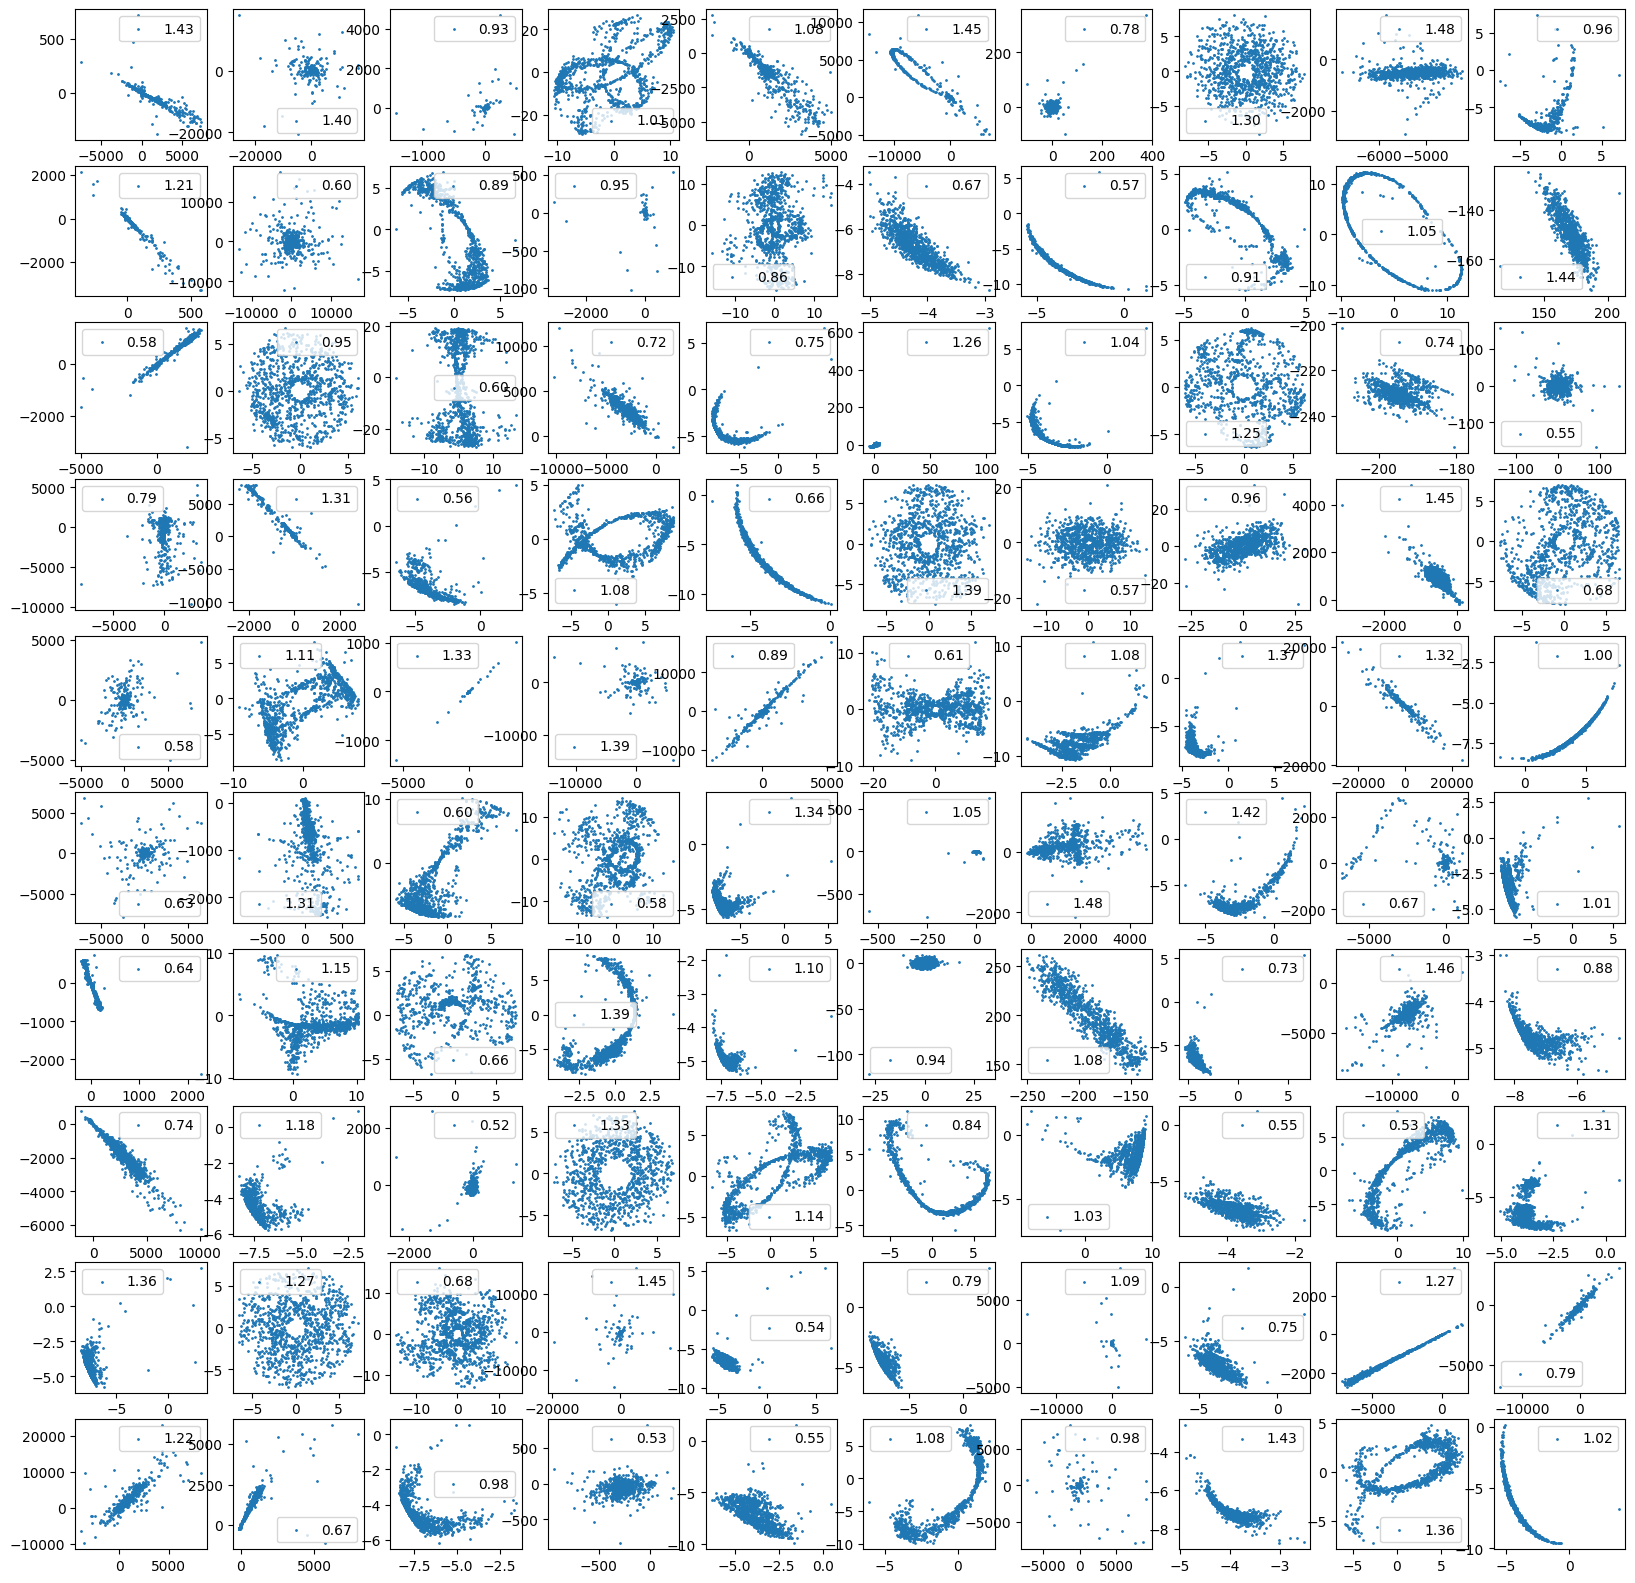

In [14]:
fig = plt.figure(figsize=(20, 20))
for idx, i in enumerate(range(0, 100)):
    data = np.load(f'../project_stream/data/streams/data/simulation_{i}.npz')
    sim_data = data['sim_data_carthesian']

    ax = fig.add_subplot(10, 10, idx+1)
    ax.scatter(sim_data[:, 0], sim_data[:, 1], s=1, label=f"{data['q2_Triaxial_halo'][0]:.2f}")
    ax.legend()